#### Name: Kristen Townsend

# PHYS 230 Lab Assignment 15

### Wednesday, April 1, 2026: Chapter 8.2-8.3
- Multivariable differential equations
- Second-order differential equations 

In [7]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt


### The problem:

Today we will solve a second-order ordinary differential equation for a simple harmonic oscillator. The standard equation is given as: 

$$\frac{d^2x}{dt^2}= -\omega^2 x $$

The general solution to this differential equation is: 

$$x(t) = c_1 \cos \omega t + c_2 \sin \omega t $$

where $c_1$ and $c_2$ can be found from initial conditions. 

For this problem, we will analyze the case of $\omega = 1$ in the range of $t=0$ to $t=50$. The initial conditions are $x=1$ and $dx/dt = 0$. 

*Problem adapted from Exercise 8.6 in the textbook*

### Part 1: Solving the second-order differential equation 

Let's solve for $x$ as a function of time. Do this in the following steps: 

#### Step 1: In a markdown, write the two simultaneous single-order differential equations that you will use to solve this second-order differential equation. 
*Double-check with the professor before moving on.*

Splitting up the second-order differential of: $$\frac{d^2x}{dt^2}= -\omega^2 x $$

The differental equation $ \frac{dx}{dt} = v $ can then be 'nested' into the previous differential, leaving $ \frac{dv}{dt} = - \omega^2 x $ as the second differential equation needed.

#### Step 2: Write a function `f(r,t)` that will calculate the two equations written in step 1. 

In [4]:
def f(r,t):
    x = r[0]
    v = r[1]
    
    # define actual differential equations
    fx = v
    fv = - omega**2 * x

    # return vector array of functions
    return np.array([fx,fv], float)

Differential equations used withhin the function:
$$ \frac{dx}{dt} = v $$
$$ \frac{dv}{dt} = - \omega^2 x $$

#### Step 3: Write a function `RK4_multi(r,t,h,f)` - like you did in the last lab - that you can use to solve any two simultaneous single-order differential equations.  

In [8]:
# define Runge-Kutta method
def RK4_multi(r,t,h,f):

    # apply fourth order Runge-Kutta method
    for i in range(len(t)):
        xpts[i] = r[0]
        vpts[i] = r[1]
        k1 = h * f(r, t[i])
        k2 = h * f(r+0.5*k1, t[i]+0.5*h)
        k3 = h * f(r+0.5*k2, t[i]+0.5*h)
        k4 = h * f(r+k3, t[i]+h)
        r += (k1 + 2*k2 + 2*k3 + k4)/6
        
    return xpts,vpts

This function is essentially a verbatim Runge-Kutta method.

The function returns two arrays of results instead of a single array to make plotting results easier as is removes a step needed which would separate the arrays to plot them regardless.

#### Step 4: Define any constants and arrays necessary for the problem and solve for $x$ and $dx/dt$ as a function of time. 

In [22]:
# initialize constants
tstart = 0.0
tend = 50.0
N = 1000
h = (tend-tstart) / N

omega = 1
x = 1.0
v = 0.0 #dx/dv

tpts = np.arange(tstart,tend+h, h)

r = np.array([x,v], float) # starting position
xpts = np.zeros(len(tpts))
vpts = np.zeros(len(tpts))

# solve for x and v
xpoints, vpoints = RK4_multi(r,tpts,h,f)

# make plot of results ------ ignore this for part 4
#plt.plot(tpts,xpoints,".b") 
#plt.plot(tpts, vpoints,".r") 
#plt.legend(["x","dx/dt"])
#plt.xlabel("t (seconds)")

#plt.show()

Arrays are initialized to keep track of results.

The function RK4_multi as defined earlier was called and simply equated into two different variables to be plotted easily.

#### Step 5: Make a plot the position $x$ vs. time. Does this agree with what you expected (add a markdown cell explaining this)? 

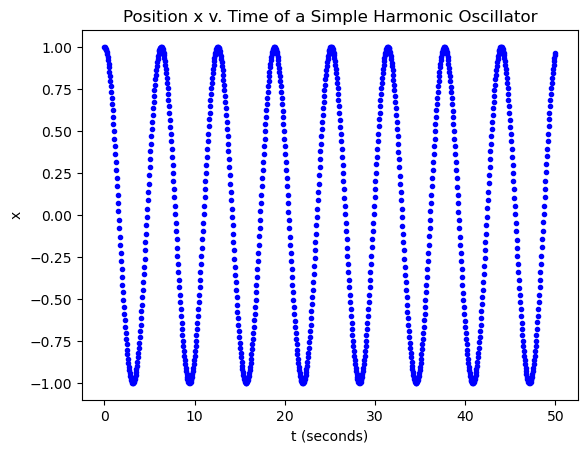

In [15]:
# plot position v. time
plt.plot(tpts,xpoints,".b") 
plt.xlabel("t (seconds)")
plt.ylabel("x")
plt.title("Position x v. Time of a Simple Harmonic Oscillator")
plt.show()

...This looks like a harmonic oscillator to me.

Thhe oscillator begins at its maximum amplitude and appears to have a full period every 2 pi (approximately 6.28). Because the angular frequency was set to zero, the period should be 2 pi. The math and the image match.

The amplitude was set to equal 1. The oscillator plotted has an amplitude of 1. 

#### Step 6: Now graph $dx/dt$ vs. $x$ instead. This is called a *phase space* plot. Interpret the result (do an internet search to understand phase space plots if need be, but your explanations must be in your own words). 

If you would like to make your graph square, you can use: 
`plt.figure(figsize=(#,#))` replacing the #'s with whatever equal dimensions you want. 

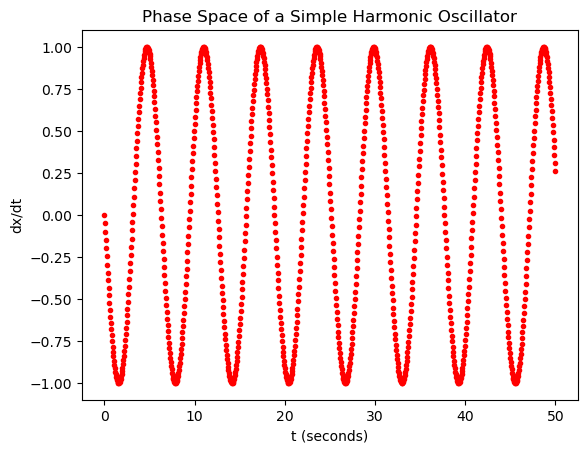

<Figure size 1000x1000 with 0 Axes>

In [41]:
# plot dx/dt v. time
plt.plot(tpts,vpoints,".r") 
plt.xlabel("t (seconds)")
plt.ylabel("dx/dt")
plt.title("Phase Space of a Simple Harmonic Oscillator")

# try and alter size of the image
plt.figure(figsize=(10,10))
plt.show()

The change of position over time can be understood as the object's velocity, and will be referred to as such moving forward. 

A phase space plot shows how the velocity changes over time to give an understanding of its evolution over time.

The phase space follows the expected oscillating form. The velocity begins at zero, which matches where the amplitude of the positional oscillation equals zero. It is then at its greatest value when the oscillator's position is equal to zero. 

I am not sure if the image size is affected within VScode or is only visible when exporting the image...

### Part 2: Variations

Test what happens to your solution when we change some parameters. 

#### Step 1: Increase the amplitude of oscillators by making the initial position larger. Reanalyze the results and plot $x$ vs. $t$ again. What can you say about the oscillations? In particular, comment on the period of oscillations - what do we expect to happen to the period when the amplitude is increased?  

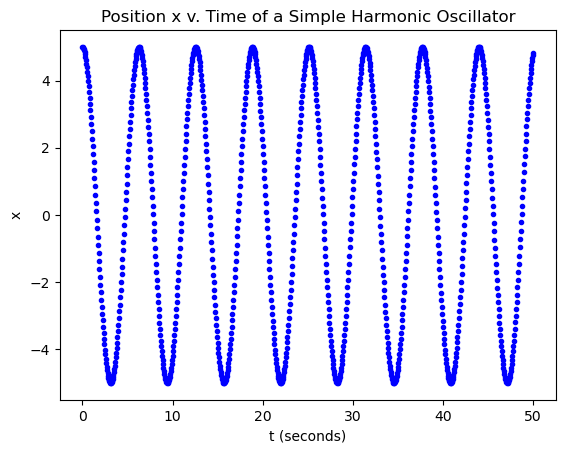

In [19]:
# change initial conditions
x = 5

# re-analyze
r = np.array([x,v], float) # starting position
xpts = np.zeros(len(tpts))
vpts = np.zeros(len(tpts))

# solve for x and v
xpoints2, vpoints2 = RK4_multi(r,tpts,h,f)

# make plot of results position v. time
plt.plot(tpts,xpoints2,".b") 
plt.xlabel("t (seconds)")
plt.ylabel("x")
plt.title("Position x v. Time of a Simple Harmonic Oscillator")
plt.show()


When the amplitude is increased, the oscillator retains the same shape of movement! As expected, the period of the oscillations does not change. The period of oscillations will not be impacted unless the angular frequency omega is effected. In this situation, the amplitude simply works as a scalar.

#### Step 2: Using the original amplitude, change the initial conditions to be $x = 0$ and $dx/dt = 1$. Analyze the results and plot position vs. time again. What do you notice about the oscillations compared to the previous step and the original in Part 1?

(You may find it helpful to plot the original results from Part 1 simultaneously on the same graph for comparison)

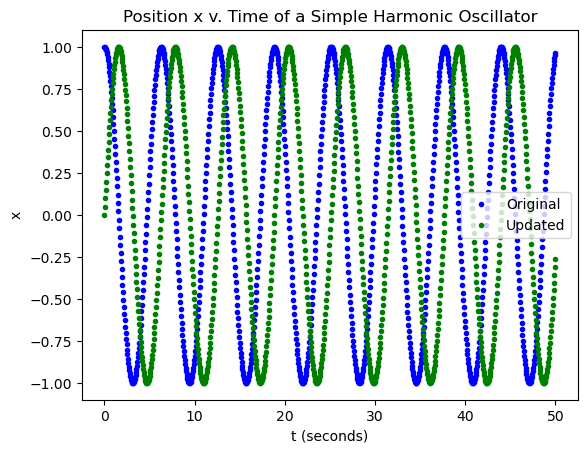

In [21]:
# update initial conditions
x = 0.0
v = 1.0 #dx/dv

# re-analyze
r = np.array([x,v], float) # starting position
xpts = np.zeros(len(tpts))
vpts = np.zeros(len(tpts))

# solve for x and v
xpoints3, vpoints3 = RK4_multi(r,tpts,h,f)

# make plot of results position v. time
# original results from part 1
plt.plot(tpts,xpoints,".b") 

# updated results
plt.plot(tpts,xpoints3,".g") 
plt.xlabel("t (seconds)")
plt.ylabel("x")
plt.legend(["Original","Updated"])
plt.title("Position x v. Time of a Simple Harmonic Oscillator")
plt.show()

The updated oscillation with the new initial conditions appears to be offset from the original oscillation by half a phase. By the time the updated oscillation reaches it's max distance, the original oscillation as returned to zero. They are identical otherwise with the same period and amplitude.

Once again, the oscillations have the same shape if only the amplitude is changed, so the updated oscillation would be slightly offset and shorter than the oscillation plotted in the step previous.

They appear like cosine and sine functions!

### Part 3: Anharmonic Oscilator 

Let's now analyze the motion of an anharmonic oscillator described by the equations
$$ \frac{d^2x}{dt} = -\omega^2 x^3 $$
Again, analyze the case of $\omega = 1$ in the range of $t=0$ to $t=30$. The initial conditions are $x=1$ and $dx/dt = 0$. 

#### Step 1: Make a graph of $x$ vs. $t$ by applying steps 1-5 from part 1 above for this new equation. 
**Hint**: You can/should reuse your `RK4_Multi` function rather than coding it up again, but be sure to complete all 5 steps 

Part 1
Splitting up the second-order differential
$$ \frac{dx}{dt} = v $$

$$ \frac{dv}{dt} = - \omega^2 x^3 $$

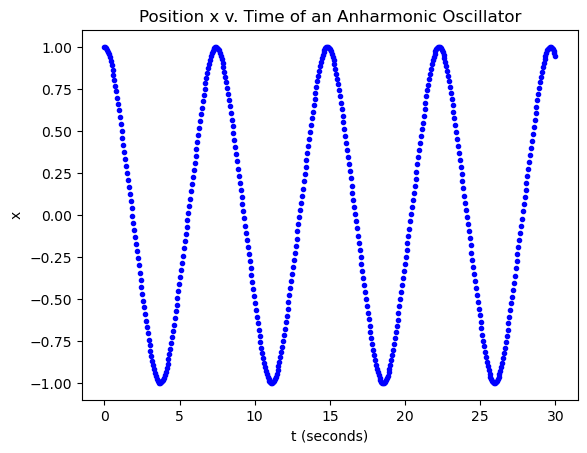

In [29]:
# step 2, define function
def F(r,t):
    x = r[0]
    v = r[1]
    
    # define actual differential equations
    fx = v
    fv = - omega**2 * x**3

    # return vector array of functions
    return np.array([fx,fv], float)

# step 3, RK4_Multi is already written

# step 4, define constants and solve
# initialize constants
tstart = 0.0
tendnew = 30.0
N = 500
h = (tendnew-tstart) / N

omega = 1
x = 1.0
v = 0.0 #dx/dv

timeAH = np.arange(tstart,tendnew+h, h)

r = np.array([x,v], float) # starting position
xpts = np.zeros(len(timeAH))
vpts = np.zeros(len(timeAH))

# solve for x and v
xcalced, vcalced = RK4_multi(r,timeAH,h,F)

# part 5, plot position v. time
plt.plot(timeAH,xcalced,".b") 
plt.xlabel("t (seconds)")
plt.ylabel("x")
plt.title("Position x v. Time of an Anharmonic Oscillator")
plt.show()

Code-wise, I only needed to update the differential equation defined in the beginning of the cell.

The period and amplidude remain the same to the previous hharmonic oscillator, but the x^3 introduced makes the peaks of motion sharper. This is especially clear when the power is increased further.


#### Step 2: Once again, vary the amplitude to see what happens when we increase the amplitude from $x=1$ to $x=2$ to $x=4$. Plot all three position vs. time graphs on the same graph (be sure to include a legend). What do you notice about an anharmonic oscillator as the amplitude increases? 

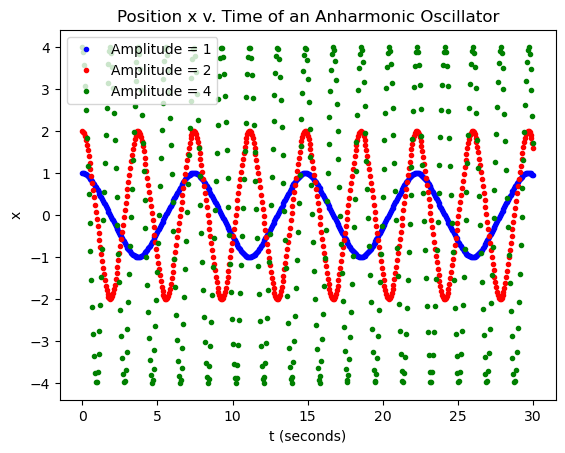

In [34]:
# altered amplitudes
x1 = 1.0
x2 = 2.0
x4 = 4.0

# amplitude x = 1
r = np.array([x1,v], float) # starting position
xpts = np.zeros(len(timeAH))
vpts = np.zeros(len(timeAH))
# solve for x and v
xcalced1, vcalced1 = RK4_multi(r,timeAH,h,F)

# amplitude x = 2
r = np.array([x2,v], float) # starting position
xpts = np.zeros(len(timeAH))
vpts = np.zeros(len(timeAH))
# solve for x and v
xcalced2, vcalced2 = RK4_multi(r,timeAH,h,F)

# amplitude x = 4
r = np.array([x4,v], float) # starting position
xpts = np.zeros(len(timeAH))
vpts = np.zeros(len(timeAH))
# solve for x and v
xcalced4, vcalced4 = RK4_multi(r,timeAH,h,F)

# plot all results
# make plot of results position v. time
plt.plot(timeAH,xcalced1,".b") 
plt.plot(timeAH,xcalced2,".r") 
plt.plot(timeAH,xcalced4,".g") 

plt.xlabel("t (seconds)")
plt.ylabel("x")
plt.legend(["Amplitude = 1","Amplitude = 2","Amplitude = 4"])
plt.title("Position x v. Time of an Anharmonic Oscillator")
plt.show()

The green oscillator (amplitude = 4) appears to be making 'bubbles' around x = 0. This seems to be a visual effect from the data points within the oscillator being slightly un-aligned as the oscillations continue.

As expected the amplitude of the oscillations change to the updated value, but the period also changed. The larger the amplitude, the smaller the period. This might be because the positional argument of the differential equations above may be 'overpowering' the angular frequency, as it now has a higher power.

#### Step 3: Now graph the *phase space* plot of the anharmonic oscillator. Include the phase space of the harmonic oscillator. In markdown, interpret the result and compare with the harmonic oscillator phase space plot. (Do this for the *original* initial conditions - they need to be the same to properly compare)

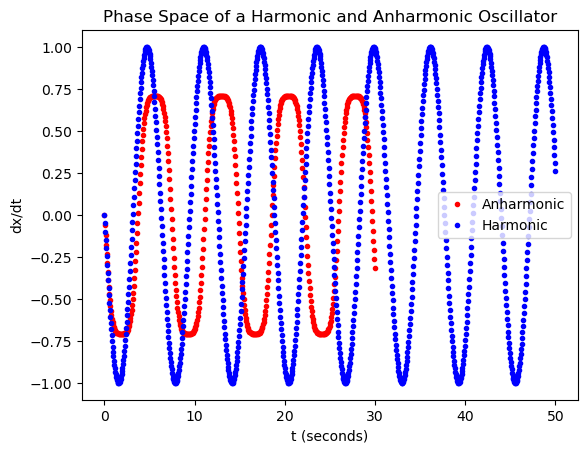

In [38]:
# plot dx/dt v. time
# anharmonic
plt.plot(timeAH,vcalced,".r") 
# harmonic
plt.plot(tpts,vpoints,".b") 

plt.legend(["Anharmonic","Harmonic"])
plt.xlabel("t (seconds)")
plt.ylabel("dx/dt")
plt.title("Phase Space of a Harmonic and Anharmonic Oscillator")
plt.show()

Compared to the harmonic phase space, the anharmonic phase space shows a much 'blunter' peak of velocity on each oscillation. This means that, while it doesn't reach the same speed, the oscillator has a more sustained speed at the velocity peaks as the position of the oscillator approaches zero.

The anharmonic phase space also has a slightly increased period than the harmonic phase space. This is consistent with the changes in period shown in the anharmonic position over time detailed previously.